# v3 **both** hidden layers — perturbation sweeps, accuracy

Visualises the **v3L12 factorial** grid: the same experiment as
[the 1st-layer notebook](../1stLayer/result_visualization.ipynb) and
[the 2nd-layer one](../2ndLayer/results_visualization.ipynb), with the two penalties
charged at **both** hidden layers at once. A per-pair spike ceiling
`relu(count - k)` sets temporal sparsity `a` along `k`, crossed with a
membrane-potential floor setting selectivity `s` (OFF / ON), at seeds 42/43/44 —
now applied to `hidden1` **and** `hidden2`, each at the full coefficient its
single-layer sibling used.

**Why this grid exists.** Neither single-layer grid produces a sparse *network*: it
produces one sparse layer and one unconstrained layer that is free to compensate, and
under v1's layer-1-only penalty it did exactly that — ρ(`s1`, `s2`) = **−0.829** in
the no-delay arm, i.e. squeezing layer 1 made layer 2 *less* selective, and the pooled
confound ρ(`a_net`, `s_net`) sat at **−0.879**. This grid is the same factorial moved
to the whole network (document 7 §1).

| arm | grid | checkpoints | row axis |
|---|---|---|---|
| no-delay | 4 `k` × 2 floor × 3 seeds | 24 | `k1 = 1, 2, 4, 8`, `k2 = k1 × 1.0` |
| with-delay | 4 `k` × 2 floor × 3 seeds | 24 | `k1 = 1, 2, 4, 8`, `k2 = k1 × **2.0**` |

`CEILING_K` lists **layer 1's** levels; layer 2's are `CEILING_K_LAYER2_RATIO` times
them, so one row knob delivers an equal *relative* cut at both layers. The delay arm's
layer 2 fires about twice as hard as its layer 1 (natural `a` 20.7–30.4 against
3.8–15.5), which is where the ×2 comes from (document 7 §3a). The delay arm also
carries `SETTLE_EPOCHS = 150`; the no-delay arm deliberately does not (document 7
§5 step 1b).

## Three injection sites, three sections

The independent variables here are pooled over both layers, but **the dependent
variable need not be** — document 7 §5 step 3 is explicit that perturbing both layers
at once is a *different and harsher* insult than perturbing either, and that per-layer
results are the primary reading with the pooled one an addition. Every eval file
therefore carries three sweeps per cell, under `sites = ['l1', 'l2', 'both']`, and
this notebook gives each its own section:

| § | site | what is perturbed | non-sparse baseline |
|---|---|---|---|
| 3 | `l1` | `hidden1` only, window `[0, 88)` | `FWP_log/*_whole_{arm}_*` |
| 4 | `l2` | `hidden2` only, window `[0, 90)` / `[0, 160)` | `FWP_log/*_2ndLayer_whole_{arm}_*` |
| 5 | `both` | `hidden1` **and** `hidden2`, each in its own window | **none exists** — see §5 |

The delay arm's layer-2 window is nearly twice layer 1's because `delay1` sits
*upstream* of that probe site and pushes layer 2's spikes as late as bin 159.

| perturbation | what it destroys | rate-preserving? | clipped to the window? |
|---|---|---|---|
| relocation | spike placement, count held exactly | yes | yes |
| jitter | spike placement, locally | yes | yes |
| shift | cross-neuron alignment (rigid per-neuron translation) | yes | **no** — deliberately |
| deletion | spikes themselves — the **general-robustness control** | **no** | n/a |

Shift and deletion are left unclipped on purpose: clipping a rigid translation would
pile spikes at the edge and merge them, turning a timing probe into a rate insult.

Every v3L12 point is the **mean over the cell's 3 seeds**; bands and error bars are
the across-seed standard deviation, read from the `per_setup` section of each results
file (the per-seed rows are kept in `per_checkpoint`). The baseline is a single model
per arm, with its own 3 perturbation repeats.

**Encoding.** `k` is an *ordered* variable, so it gets a single-hue ramp
(light → dark as `k` rises). The floor is *binary*, so it gets line style rather than
a hue. The baseline is not a cell of the factorial, so it takes neutral ink and a
dash-dot line rather than a colour slot.
Set the global `SHOW_FLOOR_OFF = False` in the setup cell to drop the
floor-OFF (high `s`) half of the grid from **every** figure below, leaving only
the floor-ON setups; the tables in §8 always list both halves. In §6, where the three sites are compared
directly, the **site** becomes the categorical variable and gets its own three hues.

> **Caveats on the baseline, carried over from both sibling notebooks.**
>
> 1. **The jitter panels are not strictly like-for-like.** The v3L12 jitter sweeps
>    clip jittered spikes to each layer's measured support; the baseline's jitter
>    (generated 2026-07-15) clips to the full `[0, T-1]` window. Jitter is local so
>    the artifact is small (≤ .026 at layer 1, document 5 §2a), but it biases the
>    baseline *downward* relative to the v3L12 curves. Relocation is fine (those
>    baselines were regenerated 2026-07-31 with support-confined destinations), and
>    shift and deletion have no destination window to correct.
> 2. **The eight baseline files do not all agree on clean accuracy** — the four
>    layer-1 files come from separate runs of the same non-sparse configuration
>    (delay .871–.890, no-delay .572–.584) while the four layer-2 files agree exactly
>    (.890 / .584). Each panel uses its own file's baseline, so every panel is
>    internally consistent; §1 draws the spread as a band rather than pretending
>    there is one number. The check is made in code.
> 3. **The relocation baseline sweep stops at `f = 0.9`** where the v3L12 sweep runs
>    to `f = 1.0`, so that one baseline curve ends one grid point short. The tables in
>    §7 label the baseline column accordingly.

The scoring, the regressions on `a` and `s`, and the H1′/H2 verdict live in
[sparse_network_bothLayer_test_progress.md](../../../docs/progress/sparse_network_bothLayer_test_progress.md)
and in the `v3_analysis/` scripts. This notebook plots **accuracy**, plus the
manipulation check (§7).

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Shared look with the fixed-weight-perturbation notebooks: sans-serif type at a
# readable size, a dotted grid over default spines, and accuracies in percent.
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 13,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "legend.fontsize": 11,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.dpi": 150,
})


# Anchor on exp_sparse_network/ by walking up from wherever the notebook runs,
# so this works from the notebook's own directory or from the repo root.
def find_experiment_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "shd" / "log").is_dir() and (candidate / "sn_data").is_dir():
            return candidate
        nested = candidate / "my_project" / "exp_sparse_network"
        if (nested / "shd" / "log").is_dir():
            return nested
    raise FileNotFoundError("could not locate exp_sparse_network/")


EXP_DIR = find_experiment_root()
FWP_DIR = EXP_DIR / "result_visualization" / "bothLayer" / "FWP_log"
print(f"experiment root: {EXP_DIR}")
print(f"baseline logs  : {FWP_DIR}")

# (key, display name, folder, v3L12 file stem, sweep key prefix,
#  {site -> baseline template}, x-axis label). The sweep key is
#  `{prefix}_{site}`, e.g. "f_sweep_l1"; the `both` site has no non-sparse
#  baseline, which is why the dict has two entries. Names and axis labels follow
#  the fixed-weight-perturbation notebooks so the two sets of figures read alike.
PERTURBATIONS = [
    ("relocation", "Per-Spike Random Relocation", "shd", "shd", "f_sweep",
     {"l1": "shd_whole_{arm}_hidden_perturbation_results.json",
      "l2": "shd_2ndLayer_whole_{arm}_hidden_perturbation_results.json"},
     r"Relocation Fraction $f$"),
    ("jitter", "Per-Spike Jitter", "jitter", "jitter", "sigma_sweep",
     {"l1": "jitter_whole_{arm}_jitter_sweep_results.json",
      "l2": "jitter_2ndLayer_whole_{arm}_evalOnly_jitter_sweep_results.json"},
     r"Jitter Std Dev $\sigma$ (ms)"),
    ("shift", "Per-Neuron Shift", "shift", "shift", "sigma_sweep",
     {"l1": "shift_whole_{arm}_shift_sweep_results.json",
      "l2": "shift_2ndLayer_whole_{arm}_evalOnly_shift_sweep_results.json"},
     r"Shift Std Dev $\sigma$ (ms)"),
    ("deletion", "Hidden Spike Deletion", "deletion", "deletion", "pd_sweep",
     {"l1": "deletion_whole_{arm}_evalOnly_deletion_sweep_results.json",
      "l2": "deletion_2ndLayer_whole_{arm}_evalOnly_deletion_sweep_results.json"},
     r"Deletion Probability $p_d$"),
]
ARMS = [("nodelay", "No Delay"), ("delay", "With Delay")]
SITES = [("l1", "hidden layer 1"), ("l2", "hidden layer 2"),
         ("both", "both hidden layers")]
# Title-case site names, for the figure titles in sections 3-5.
SITE_TITLE = {"l1": "1st Hidden Layer", "l2": "2nd Hidden Layer",
              "both": "Both Hidden Layers"}

# Accuracies are plotted in percent, matching the perturbation notebooks.
# Unconstrained firing measured on the 27 v1 checkpoints (document 7 §2a) -- the
# reference each ceiling is pushing down from, per layer and pooled over the pair.
NATURAL_A = {
    "nodelay": {"l1": (3.06, 11.49), "l2": (7.49, 12.46), "net": (5.47, 11.87)},
    "delay": {"l1": (3.82, 15.47), "l2": (20.71, 30.44), "net": (14.47, 22.60)},
}
# Observational rho from the same pass. The pooled figure is the acceptance
# target: -0.879 fails |rho| <= 0.5 in the no-delay arm, +0.042 already passes in
# the delay arm. `s1s2` is the design's motivating finding, not an acceptance
# criterion -- it must come back POSITIVE or the column knob is not a
# network-wide selectivity manipulation.
OBSERVED_RHO = {
    "nodelay": {"l1": -0.943, "l2": +0.829, "net": -0.879, "s1s2": -0.829},
    "delay": {"l1": -0.455, "l2": +0.427, "net": +0.042, "s1s2": +0.203},
}
# Each layer's own measured temporal support, per arm (document 7 §5 step 3).
SUPPORT_BINS = {"nodelay": {"l1": 88, "l2": 90}, "delay": {"l1": 88, "l2": 160}}


def shade(base_color, frac):
    """Return a lighter/darker variant of ``base_color`` keeping its hue.

    ``frac`` in ``[0, 1]`` maps the lightest variant (0, blended toward white)
    to the darkest variant (1, blended toward black), so higher ceilings can be
    drawn in a deeper shade of the same colour.
    """
    rgb = np.array(mcolors.to_rgb(base_color))
    lightest = rgb + (1.0 - rgb) * 0.55
    darkest = rgb * 0.45
    return tuple(lightest + (darkest - lightest) * frac)


# `k` is ordered -> one-hue ordinal ramp, light to dark, built with the same
# `shade` helper the perturbation notebooks use for their training levels. The
# floor is binary -> line style and a contrasting hue, not a step in the ramp.
K_LEVELS_ALL = (1.0, 2.0, 4.0, 8.0)
K_COLOURS = {k: shade("#2ca02c", index / (len(K_LEVELS_ALL) - 1))
             for index, k in enumerate(K_LEVELS_ALL)}
# Delay mode in the perturbation notebooks is dashed with 'x' against solid with
# a filled circle; the same pairing marks the binary floor switch here.
FLOOR_STYLE = {0.0: dict(linestyle="--", marker="x", markersize=6),
               1.0: dict(linestyle="-", marker="o", markersize=4)}
FLOOR_COLOUR = {0.0: "#1f77b4", 1.0: "#d62728"}
FLOOR_LABEL = {0.0: "floor OFF (high s)", 1.0: "floor ON (low s)"}
# Global display switch. False hides every floor-OFF series, so the figures
# show only the floor-ON half of the grid. Figures only -- the tables in §8
# always list both halves.
SHOW_FLOOR_OFF = False
# In §6 the injection site is the categorical variable and takes the hues, drawn
# from the same tab10 triple the perturbation notebooks use for their datasets.
SITE_COLOUR = {"l1": "#1f77b4", "l2": "#2ca02c", "both": "#d62728"}

INK, INK_MUTED = "black", "#4d4d4d"

# The non-sparse baseline is a reference, not a series: neutral ink, dash-dot.
BASELINE_STYLE = dict(color=INK, linestyle="-.", marker="s", markersize=4,
                      linewidth=1.6, zorder=5)


def load_results(arm: str, folder: str, stem: str) -> dict:
    """Return the whole v3L12 results file for one arm and one perturbation."""
    path = EXP_DIR / folder / "log" / f"sparse_whole_{arm}_v3L12_{stem}_eval.json"
    return json.loads(path.read_text())


def load_per_setup(arm: str, folder: str, stem: str) -> dict:
    """Return the seed-averaged v3L12 rows for one arm and one perturbation."""
    return load_results(arm, folder, stem)["per_setup"]


def load_baseline(arm: str, templates: dict, site: str):
    """Return the non-sparse sweep for one site: {grid point -> (mean, std)}.

    Accuracies come back in percent, like every other curve in this notebook.
    The `both` site has no non-sparse counterpart, so this returns None there.
    """
    if site not in templates:
        return None
    raw = json.loads((FWP_DIR / templates[site].format(arm=arm)).read_text())
    return {float(point): (entry["mean"] * 100, entry["std"] * 100)
            for point, entry in raw.items()}


def k_levels(arm: str) -> list:
    """Return layer 1's ceiling levels actually present in this arm's grid."""
    rows = load_per_setup(arm, "shd", "shd").values()
    return sorted({row["ceiling_k"] for row in rows})


def k_ratio(arm: str) -> float:
    """Return CEILING_K_LAYER2_RATIO as recorded in the checkpoints themselves."""
    rows = load_results(arm, "shd", "shd")["per_checkpoint"].values()
    ratios = {row["ceiling_k_layer2_ratio"] for row in rows}
    if len(ratios) != 1:
        raise ValueError(f"{arm}: inconsistent layer-2 ratio {ratios}")
    return float(ratios.pop())


def k_tick_labels(arm: str) -> list:
    """Label the row axis with both layers' ceilings when they differ."""
    ratio = k_ratio(arm)
    if ratio == 1.0:
        return [f"{k:g}" for k in k_levels(arm)]
    return [f"{k:g}\n({k * ratio:g})" for k in k_levels(arm)]


def k_axis_label(arm: str) -> str:
    """Name the row axis, spelling out layer 2's scaled ceiling when it differs."""
    if k_ratio(arm) == 1.0:
        return r"Ceiling $k$ (Both Layers)"
    return rf"Ceiling $k_1$ ($k_2 = k_1 \times {k_ratio(arm):g}$, in brackets)"


# Ceiling levels left out of the figures. `k = 2` tracks its neighbours closely
# enough that the extra curve only crowds the ramp; the grid itself is untouched
# and the remaining levels keep their shades, so the figures stay comparable.
HIDDEN_K_LEVELS = (2.0,)


def shown_k_colours() -> dict:
    """Return the ceiling -> colour map restricted to the drawn levels."""
    return {k: colour for k, colour in K_COLOURS.items() if show_k(k)}


def show_k(ceiling_k: float) -> bool:
    """Return True if a setup with this ceiling should be drawn."""
    return float(ceiling_k) not in HIDDEN_K_LEVELS


def floor_levels() -> list:
    """Return the floor levels to draw, honouring SHOW_FLOOR_OFF."""
    return [floor for floor in (0.0, 1.0) if SHOW_FLOOR_OFF or floor == 1.0]


def show_floor(floor_strength: float) -> bool:
    """Return True if a setup with this floor strength should be drawn."""
    return float(floor_strength) in floor_levels()


def bar_offset(index: int, count: int, width: float) -> float:
    """Return the x offset of bar `index` of `count`, so the group stays centred."""
    return (index - (count - 1) / 2) * (width + 0.02)


def style_axis(axis) -> None:
    """Apply the perturbation notebooks' axis look: a dotted grid under the data."""
    axis.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)
    axis.set_axisbelow(True)


def label_panel(axis, index: int) -> None:
    """Tag a panel with its bold "(a)", "(b)", ... letter, above its top-left.

    Right-aligned at the axes' left edge: the panel titles are wide enough to
    reach a left-aligned label and overlap it.
    """
    axis.text(-0.02, 1.04, f"({chr(ord('a') + index)})", transform=axis.transAxes,
              ha="right", fontsize=16, fontweight="bold")


# Check that all eight v3L12 files carry all three sites, that every cell really
# carries three seeds, and that all eight baseline files are present.
for arm, _ in ARMS:
    windows = SUPPORT_BINS[arm]
    print(f"{arm}  (target layers [1, 2], k2 = k1 x {k_ratio(arm):g}, "
          f"windows L1 [0, {windows['l1']}) / L2 [0, {windows['l2']}))")
    for key, _, folder, stem, prefix, templates, _ in PERTURBATIONS:
        results = load_results(arm, folder, stem)
        rows = results["per_setup"]
        layers = {tuple(row["target_layers"])
                  for row in results["per_checkpoint"].values()}
        seeds = {row["n_seeds"] for row in rows.values()}
        cleans = {site: load_baseline(arm, templates, site)
                  for site, _ in SITES}
        clean_text = "  ".join(
            f"{site} {sweep[min(sweep)][0]:.1f}%" if sweep else f"{site} --"
            for site, sweep in cleans.items())
        print(f"  {key:<11} v3L12: {len(rows)} setups, "
              f"{len(results['per_checkpoint'])} checkpoints, seeds {seeds}, "
              f"target_layers {layers}, sites {results['sites']}  |  "
              f"baseline clean: {clean_text}")


experiment root: D:\IC_2025\IRP\workspace\my_project\exp_sparse_network
baseline logs  : D:\IC_2025\IRP\workspace\my_project\exp_sparse_network\result_visualization\bothLayer\FWP_log
nodelay  (target layers [1, 2], k2 = k1 x 1, windows L1 [0, 88) / L2 [0, 90))
  relocation  v3L12: 8 setups, 24 checkpoints, seeds {3}, target_layers {(1, 2)}, sites ['l1', 'l2', 'both']  |  baseline clean: l1 58.4%  l2 58.4%  both --
  jitter      v3L12: 8 setups, 24 checkpoints, seeds {3}, target_layers {(1, 2)}, sites ['l1', 'l2', 'both']  |  baseline clean: l1 57.2%  l2 58.4%  both --
  shift       v3L12: 8 setups, 24 checkpoints, seeds {3}, target_layers {(1, 2)}, sites ['l1', 'l2', 'both']  |  baseline clean: l1 57.2%  l2 58.4%  both --
  deletion    v3L12: 8 setups, 24 checkpoints, seeds {3}, target_layers {(1, 2)}, sites ['l1', 'l2', 'both']  |  baseline clean: l1 57.3%  l2 58.4%  both --
delay  (target layers [1, 2], k2 = k1 x 2, windows L1 [0, 88) / L2 [0, 160))
  relocation  v3L12: 8 setups, 24 

## 1. Clean accuracy across the grid

The unperturbed accuracy every curve in §3–§5 starts from. Worth reading before any
perturbation result: a normalised damage score divides by this number, so a cell whose
clean accuracy is unusual will move the score for reasons that have nothing to do with
timing.

The dash-dot line is the non-sparse network's clean accuracy, and the band around it is
the spread across the eight baseline files. That spread is run-to-run variation of the
same non-sparse configuration, not a site effect — clean accuracy is a property of the
model, and the perturbation site cannot change it.

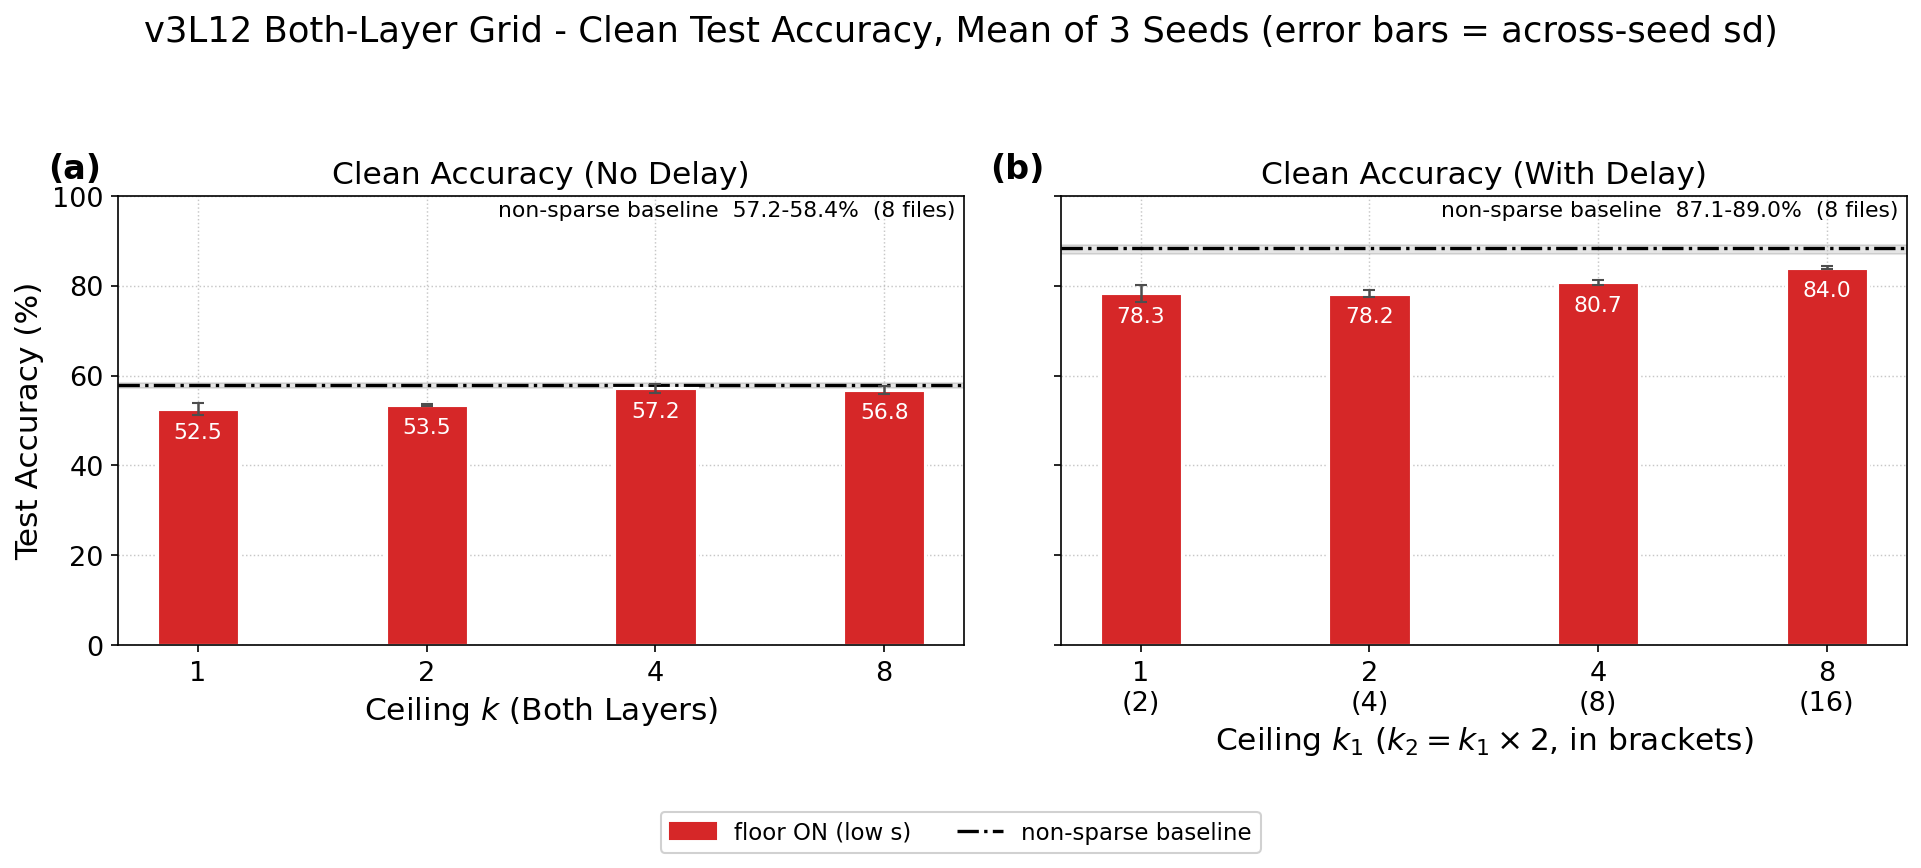

In [2]:
figure, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
width = 0.36

for col, (arm, arm_label) in enumerate(ARMS):
    axis = axes[col]
    per_setup = load_per_setup(arm, "shd", "shd")
    levels = k_levels(arm)
    positions = np.arange(len(levels))

    # Non-sparse reference: every baseline file's own clean accuracy, both sites.
    clean_baselines = []
    for *_, templates, _ in PERTURBATIONS:
        for site in ("l1", "l2"):
            clean_baselines.append(load_baseline(arm, templates, site)[0.0][0])
    low, high = min(clean_baselines), max(clean_baselines)
    if high - low > 1e-9:
        axis.axhspan(low, high, color=INK, alpha=0.10, zorder=0)
        caption = f"non-sparse baseline  {low:.1f}-{high:.1f}%  (8 files)"
    else:
        caption = f"non-sparse baseline  {low:.1f}%  (all 8 files agree)"
    axis.axhline(float(np.mean(clean_baselines)), color=INK, linestyle="-.",
                 linewidth=1.6, zorder=1)
    # Caption in the corner, not on the line: the bars can sit either side of the
    # baseline, so a label anchored to it would land on top of them.
    axis.text(0.99, 0.99, caption, transform=axis.transAxes, ha="right",
              va="top", fontsize=10.5, color=INK)

    drawn_floors = floor_levels()
    for index, floor in enumerate(drawn_floors):
        rows = [per_setup[f"k{k:g}_floor{floor:g}"] for k in levels]
        means = [row["clean_acc"] * 100 for row in rows]
        errs = [row["clean_acc_std"] * 100 for row in rows]
        offset = bar_offset(index, len(drawn_floors), width)
        axis.bar(positions + offset, means, width, yerr=errs, capsize=3,
                 color=FLOOR_COLOUR[floor], edgecolor="white", linewidth=1.5,
                 error_kw=dict(ecolor=INK_MUTED, lw=1.2), zorder=2)
        # Values sit inside the bar, so they cannot collide with the baseline.
        for position, value in zip(positions + offset, means):
            axis.text(position, value - 2.8, f"{value:.1f}", ha="center",
                      va="top", fontsize=10.5, color="white", zorder=3)

    axis.set_xticks(positions)
    axis.set_xticklabels(k_tick_labels(arm))
    axis.set_xlabel(k_axis_label(arm))
    style_axis(axis)
    axis.set_title(f"Clean Accuracy ({arm_label})")
    label_panel(axis, col)
    if col == 0:
        axis.set_ylabel("Test Accuracy (%)")

axes[0].set_ylim(0.0, 100.0)

handles = [plt.Rectangle((0, 0), 1, 1, color=FLOOR_COLOUR[floor],
                        label=FLOOR_LABEL[floor])
           for floor in floor_levels()]
handles.append(plt.Line2D([], [], color=INK, linestyle="-.", linewidth=1.6,
                          label="non-sparse baseline"))
figure.legend(handles=handles, loc="lower center", ncol=3, framealpha=0.9,
              fontsize=11, bbox_to_anchor=(0.5, -0.08))
figure.suptitle("v3L12 Both-Layer Grid - Clean Test Accuracy, Mean of 3 Seeds "
                "(error bars = across-seed sd)", y=1.01, fontsize=17)
figure.tight_layout(rect=(0, 0.02, 1, 0.96))
plt.show()


## 2. How to read the three site sections

Sections 3, 4 and 5 are the **same figure three times**, differing only in where the
perturbation was injected. Rows are the two arms, columns the four perturbations, and
all eight panels of a figure share one y-axis so the arms can be compared directly —
the no-delay arm simply starts much lower.

Two readings per panel, and they are independent of each other:

- the **spread between the coloured curves** is what the factorial is about — a panel
  where the coloured curves lie on top of one another says the perturbation does not
  distinguish the cells, whatever it does to accuracy;
- the **gap to the black baseline** is what the sparsity penalty cost. Note that this
  is not a like-for-like comparison of *robustness*: the baseline is a different, more
  accurate model, so a curve below it may simply be starting lower (§1).

The three figures share one plotting function, defined below, so that nothing but the
site can differ between them.

**One thing the three sections cannot settle between them.** ρ(`a1`, `a2`) is +0.96 /
+0.84 observationally and both knobs here act on both layers, so `a1` and `a2` move
together **by construction** (document 7 §2b point 4). Comparing the `l1` and `l2`
sections tells you where the *insult* lands, not which layer's sparsity caused an
effect. Attribution is what the two single-layer grids are for.

In [3]:
def plot_site_sweeps(site: str) -> None:
    """Draw the 2 arms x 4 perturbations accuracy figure for one injection site.

    Rows are the two delay arms and columns the four perturbations; every panel
    is titled with both, so the y-axis carries only the accuracy label. The
    ceiling ramp and the non-sparse baseline are named once, in the top-row
    deletion panel, whose upper corners the downhill sweeps leave empty.

    Args:
        site: one of "l1", "l2", "both" -- selects the `{prefix}_{site}` sweeps.
    """
    figure, axes = plt.subplots(2, 4, figsize=(20, 9), sharey=True)
    drew_baseline = False

    for row, (arm, arm_label) in enumerate(ARMS):
        for col, (key, name, folder, stem, prefix, templates, xlabel) in \
                enumerate(PERTURBATIONS):
            axis = axes[row][col]
            field = f"{prefix}_{site}"

            for entry in load_per_setup(arm, folder, stem).values():
                if not (show_floor(entry["floor_strength"])
                        and show_k(entry["ceiling_k"])):
                    continue
                grid = [float(point) for point in entry[field]]
                means = np.array([entry[field][p]["mean"] for p in entry[field]]) * 100
                stds = np.array([entry[field][p]["std"] for p in entry[field]]) * 100
                colour = K_COLOURS[entry["ceiling_k"]]
                axis.plot(grid, means, color=colour, linewidth=1.6,
                          markeredgecolor=colour,
                          **FLOOR_STYLE[entry["floor_strength"]])
                axis.fill_between(grid, means - stds, means + stds,
                                  color=colour, alpha=0.15, linewidth=0)

            baseline = load_baseline(arm, templates, site)
            if baseline is not None:
                drew_baseline = True
                points = sorted(baseline)
                base_means = np.array([baseline[p][0] for p in points])
                base_stds = np.array([baseline[p][1] for p in points])
                axis.plot(points, base_means, **BASELINE_STYLE)
                axis.fill_between(points, base_means - base_stds,
                                  base_means + base_stds, color=INK, alpha=0.12,
                                  linewidth=0, zorder=4)

            style_axis(axis)
            axis.set_xlabel(xlabel)
            axis.set_title(f"{name} ({arm_label})")
            label_panel(axis, row * len(PERTURBATIONS) + col)
            if col == 0:
                axis.set_ylabel("Test Accuracy (%)")

    axes[0][0].set_ylim(0.0, 100.0)

    ceiling_handles = [plt.Line2D([], [], color=colour, linewidth=1.6,
                                  label=f"$k_1$ = {k:g}")
                       for k, colour in shown_k_colours().items()]
    # The floor styles only need naming when both halves of the grid are drawn;
    # with one floor level the line style carries no information.
    reference_handles = []
    if len(floor_levels()) > 1:
        reference_handles += [plt.Line2D([], [], color=INK_MUTED, linewidth=1.6,
                                         label=FLOOR_LABEL[floor],
                                         **FLOOR_STYLE[floor])
                              for floor in floor_levels()]
    if drew_baseline:
        reference_handles.append(plt.Line2D([], [], label="non-sparse baseline",
                                            **BASELINE_STYLE))

    # The deletion panel runs downhill in every arm, leaving both of its upper
    # corners free for the two legends. Registering the first as an artist keeps
    # it when the same axes gains the second.
    deletion_col = next(col for col, entry in enumerate(PERTURBATIONS)
                        if entry[0] == "deletion")
    legend_axis = axes[0][deletion_col]
    ceiling_legend = legend_axis.legend(handles=ceiling_handles, loc="upper right",
                                        framealpha=0.9, title=r"Ceiling $k_1$",
                                        fontsize=10)
    legend_axis.add_artist(ceiling_legend)
    if reference_handles:
        legend_axis.legend(handles=reference_handles, loc="upper left",
                           framealpha=0.9, fontsize=10)

    figure.suptitle(
        f"Sparsity Controlled Network Perturbation Experiments "
        f"on {SITE_TITLE[site]}", y=1.01, fontsize=17)
    figure.tight_layout()
    plt.show()


print("plot_site_sweeps() ready -- sites:",
      ", ".join(site for site, _ in SITES))


plot_site_sweeps() ready -- sites: l1, l2, both


## 3. Perturbation injected at **hidden layer 1** (`site = l1`)

`hidden1` is perturbed inside its measured support `[0, 88)`, in both arms; `hidden2`
is left alone and receives whatever layer 1 now emits. This is the sweep that is
directly comparable, cell for cell, with the
[1st-layer grid](../1stLayer/result_visualization.ipynb) — same `k`, same floor, same
seeds, same window, same probe — the only difference being that here layer 2 is also
under penalty during training.

Its baseline is `FWP_log/*_whole_{arm}_*`: the non-sparse network perturbed at *its*
first hidden layer.

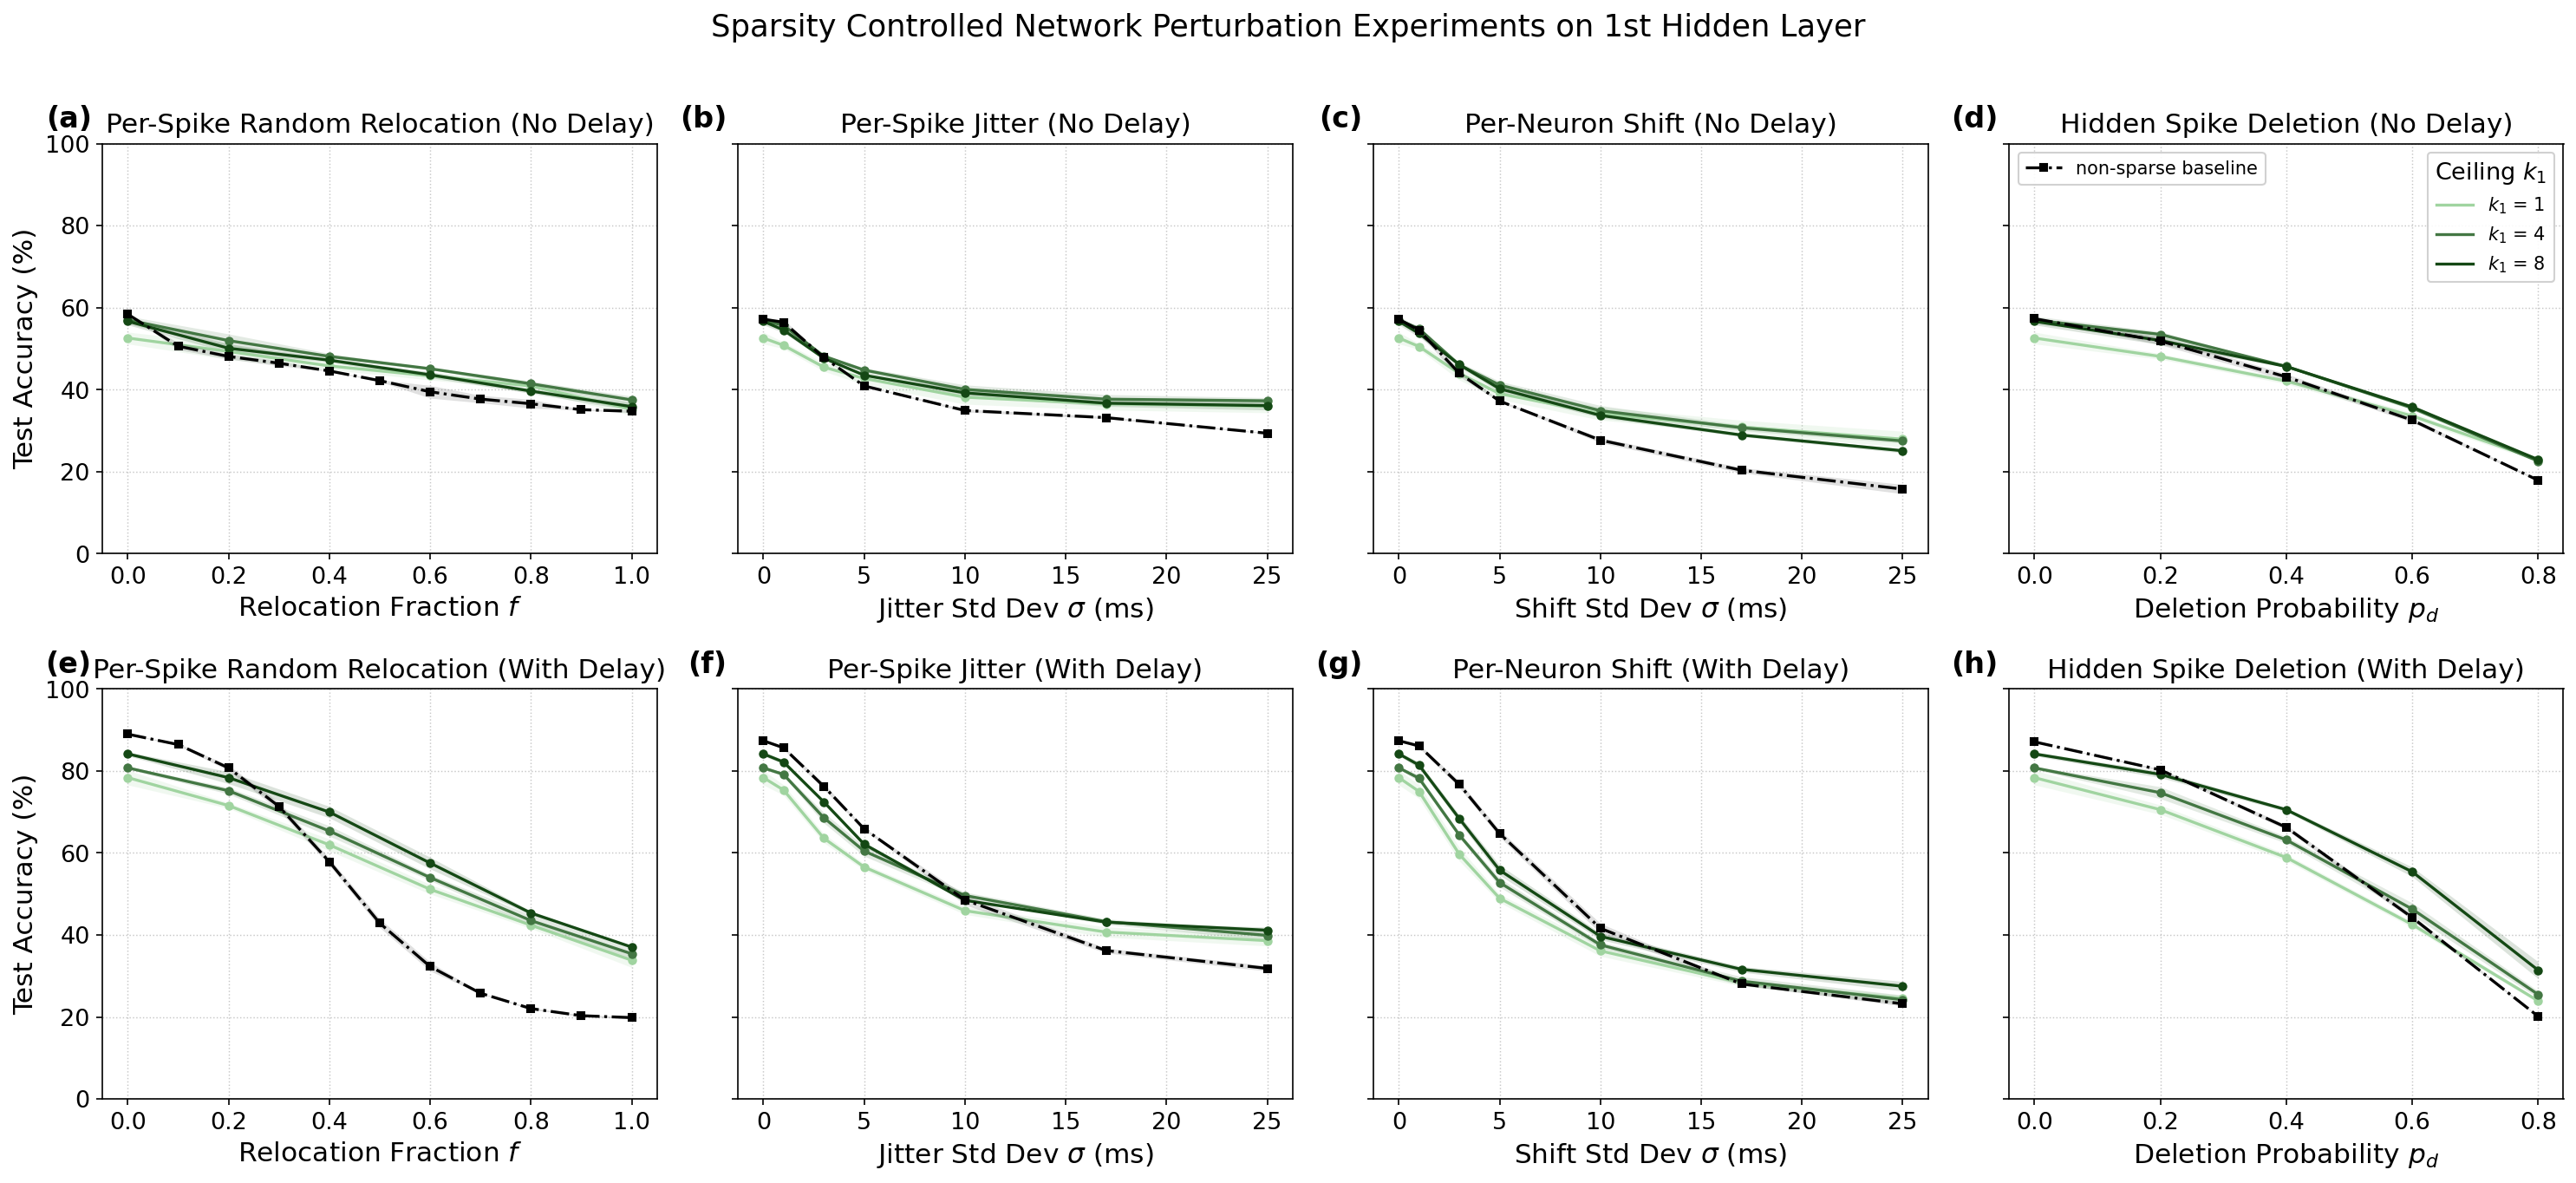

In [4]:
plot_site_sweeps("l1")

## 4. Perturbation injected at **hidden layer 2** (`site = l2`)

`hidden2` is perturbed inside its own measured support — `[0, 90)` in the no-delay arm
but `[0, 160)` in the delay arm, because `delay1` sits *upstream* of this probe site
and pushes layer 2's spikes as late as bin 159. `hidden1` is left intact, so the code
that reaches the readout has already been re-encoded once by `fc2` before the insult
lands.

Getting the delay handling wrong here would silently measure the wrong tensor rather
than raise an error (document 7 §5 step 3), which is why the window is per layer *and*
per arm rather than a single constant.

Its baseline is `FWP_log/*_2ndLayer_whole_{arm}_*`: the non-sparse network perturbed at
*its* second hidden layer. Comparing this section against §3 says how much of the
network's timing sensitivity sits at each depth — but see §2 on what it cannot say.

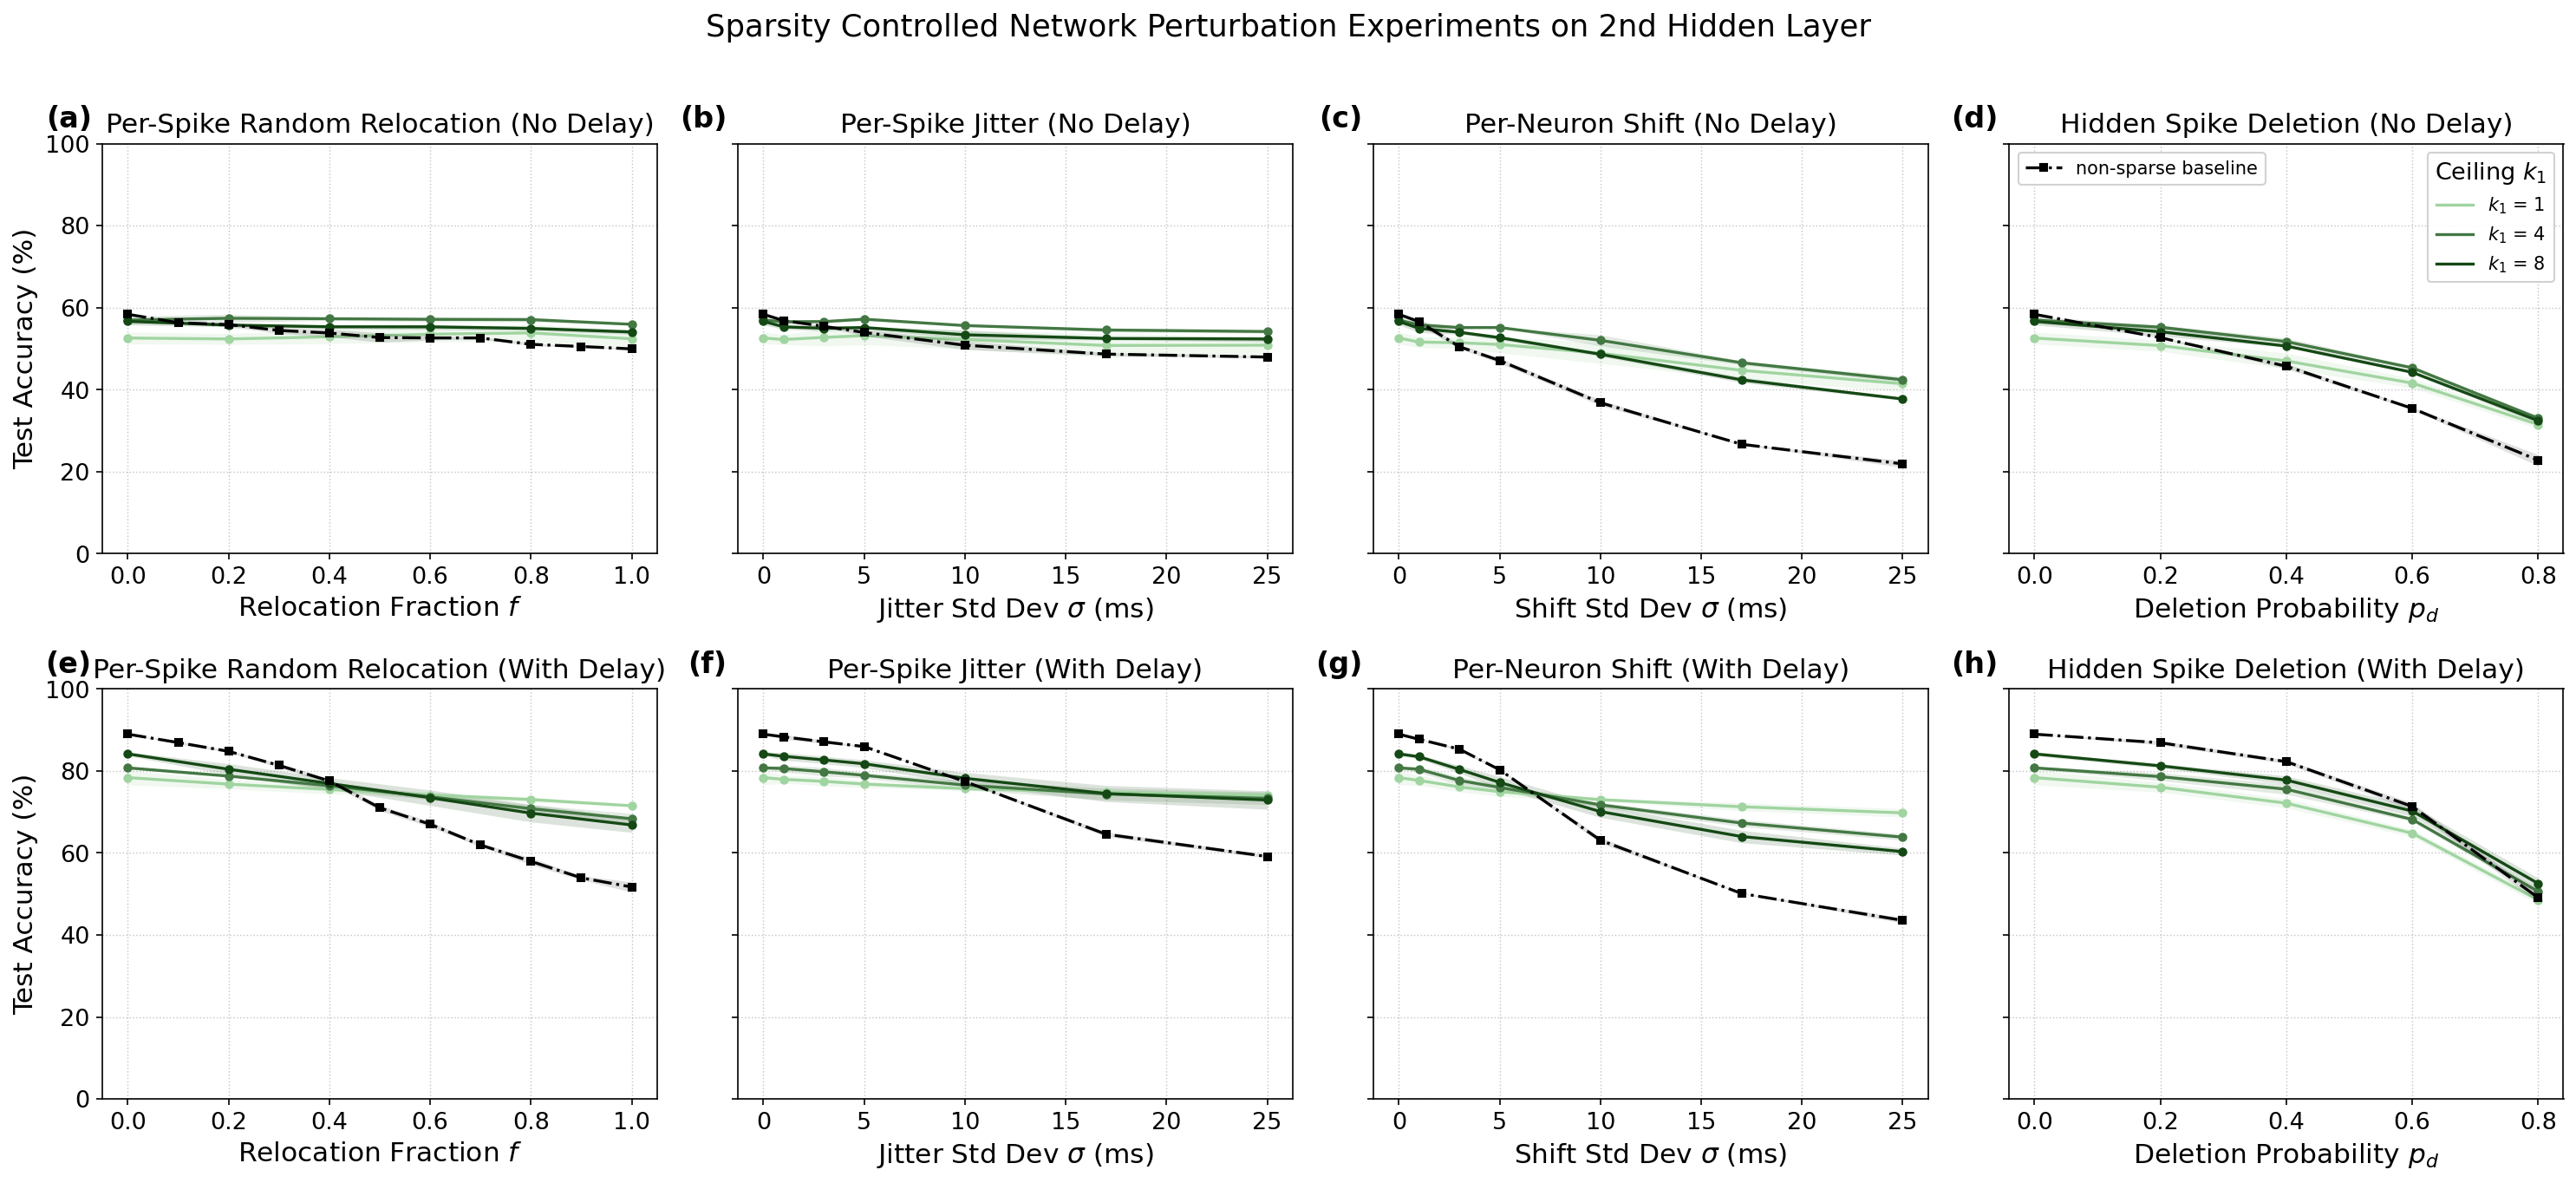

In [5]:
plot_site_sweeps("l2")

## 5. Perturbation injected at **both hidden layers** (`site = both`)

Both hidden layers are perturbed in the same pass, each inside its own window. This is
the site that matches the independent variable: the grid manipulates the whole network,
and this sweep insults the whole network.

**It is a harsher insult than either single-layer sweep, and not a sum of them.** The
perturbation at layer 1 changes what layer 2 receives, and layer 2 is then perturbed
again on top of that — the damage compounds through the depth rather than adding. Read
this section as its own quantity, not as a check on §3 and §4.

> **There is no non-sparse baseline for this site.** The
> `exp_fixed_weight_perturbation` sweeps were only ever generated one layer at a time,
> so `FWP_log/` has a `*_whole_*` set and a `*_2ndLayer_whole_*` set and nothing that
> perturbs both. The panels below therefore carry no black reference line, and the code
> omits it rather than substituting one of the single-layer files — which would put a
> strictly gentler insult on the same axes and read as if the sparse networks had done
> badly. Producing the missing baseline is a one-script job if this comparison is ever
> needed.

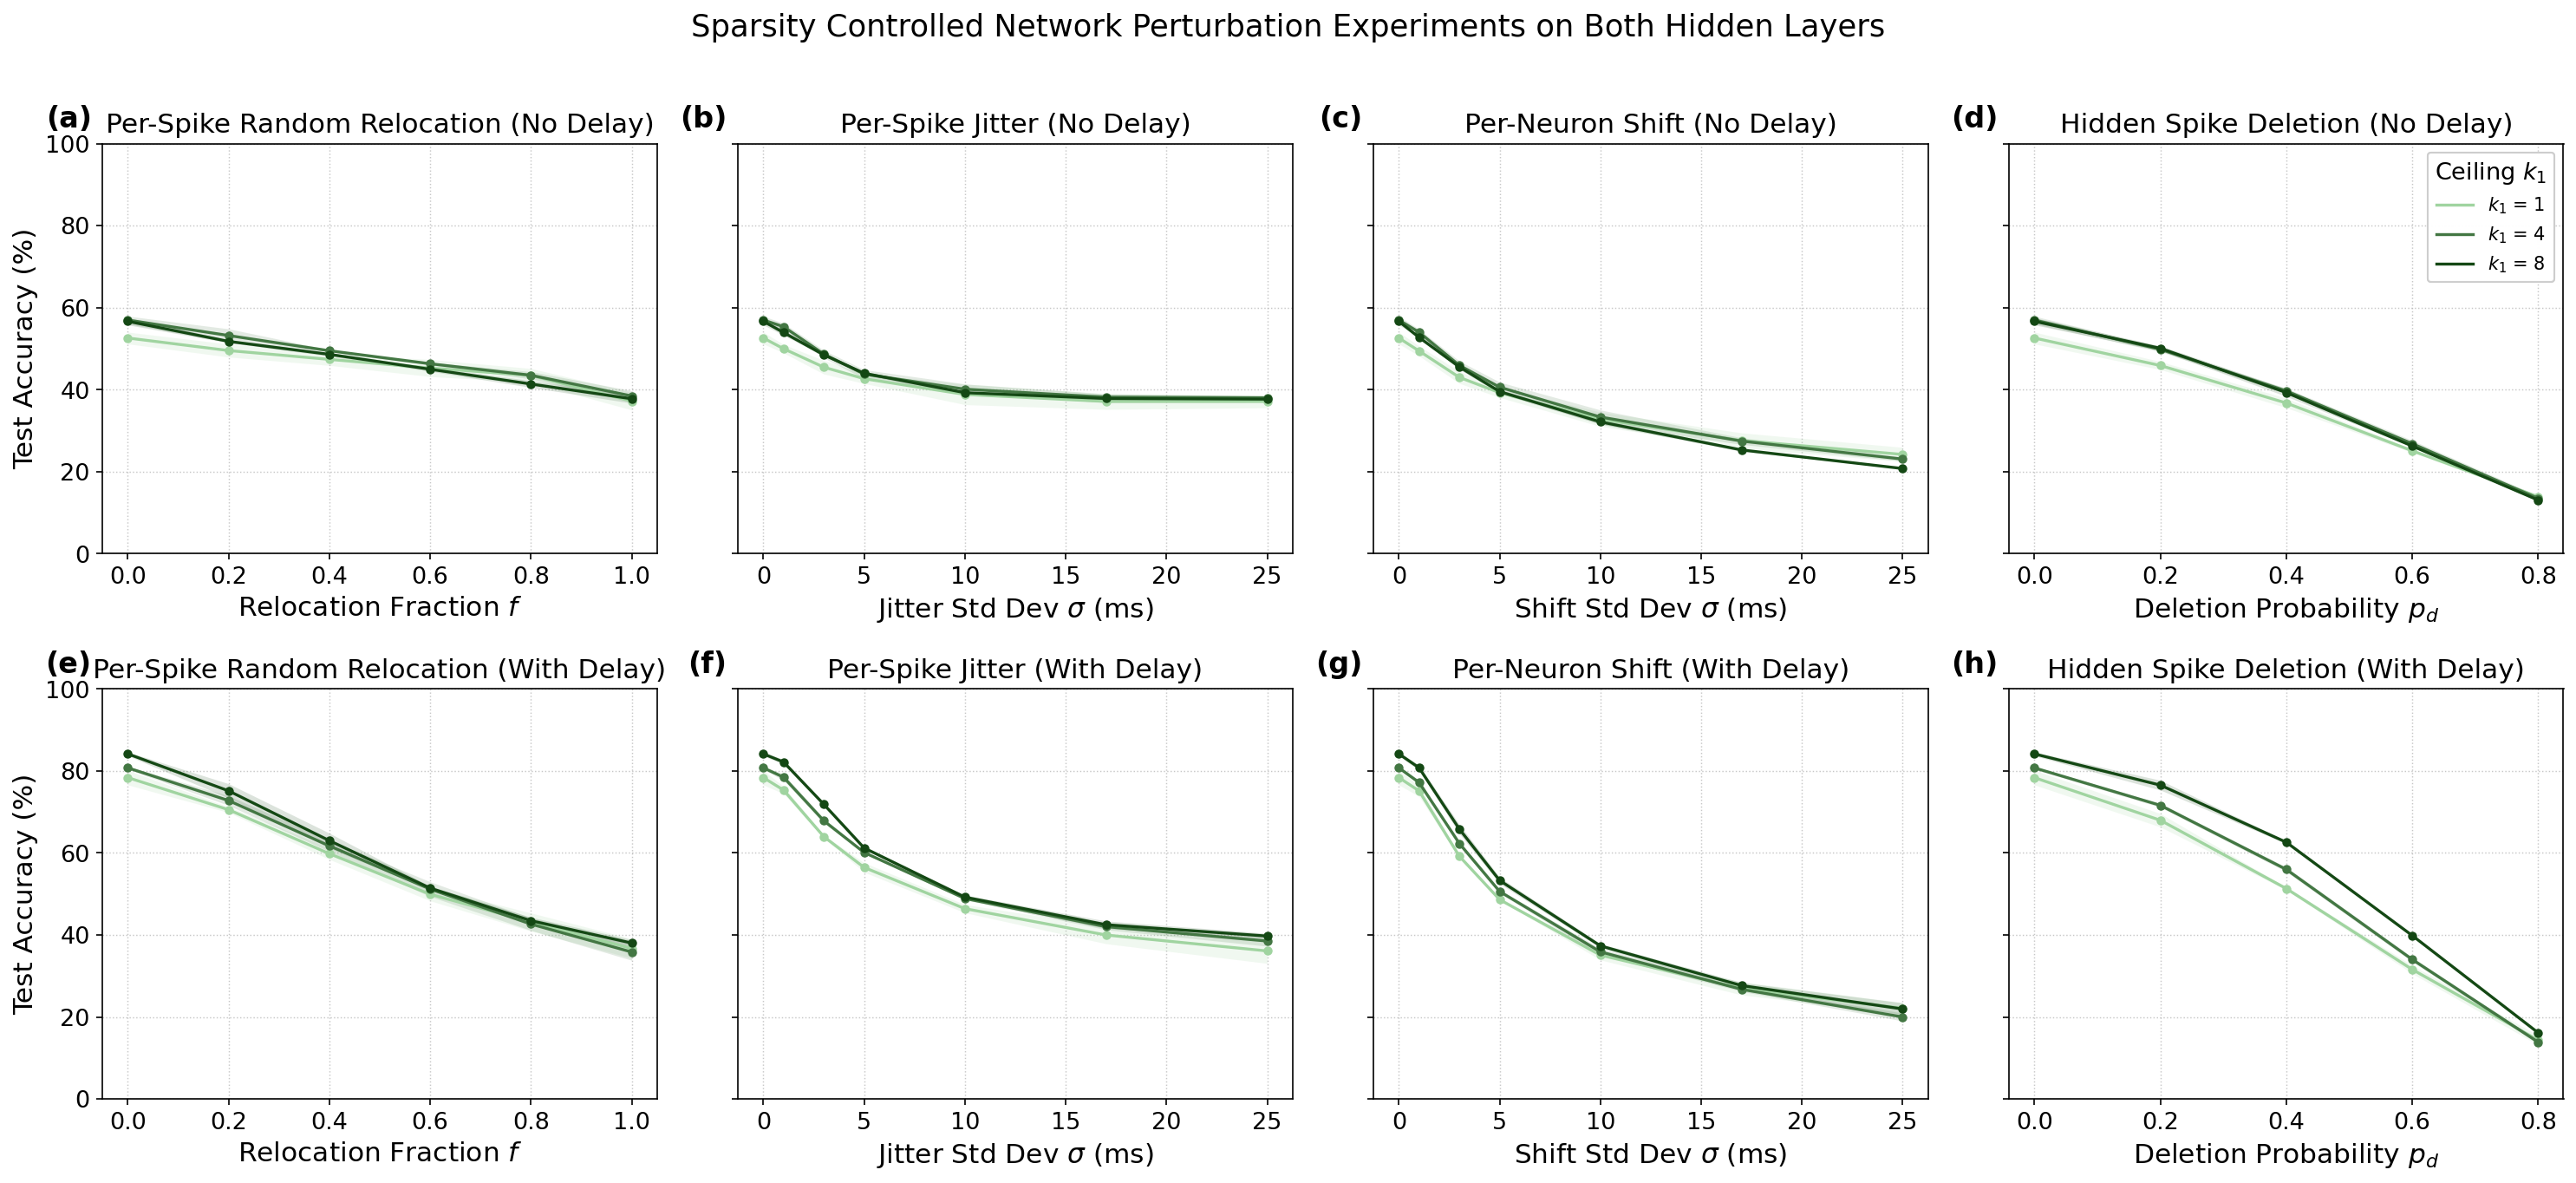

In [6]:
plot_site_sweeps("both")